# Training a Tiny Hypencoder That Really Works

**Lab companion to "Hypencoders: Scoring Embeddings with Query-specific Neural Nets"**
(AI-Powered Search guest session, Andreas Eriksen)

In this lab we train two small retrieval models from scratch, on your CPU, in a
few minutes: the well-known standard **bi-encoder** (documents and queries become vectors, scored by
how well they point the same way) and then a **hypencoder** (each document becomes a
vector, each query becomes a small neural network that takes a document vector as input and produces a score).
We give both models the same data, the same training recipe, and run the same eval on both, showing the
resulting difference in capacity for a harder type of query. At the end, we show how you can really run
these trained models inside a real search engine's ranking language.

## Our toy use case

We want a use case small enough to train quickly on a laptop, but with a real difference
in *query difficulty*. So we randomly generate documents with 4 properties out of 32, like
`item has attr_7 attr_19 attr_2 attr_30`. Queries come in three kinds:

| kind   | query text                     | a document is relevant if     |
|--------|--------------------------------|-------------------------------|
| single | `has attr_a`                   | it has a                      |
| and    | `both attr_a and attr_b`       | it has a **and** b            |
| xor    | `exactly one of attr_a attr_b` | it has **exactly one** of a,b |

The first two reward "the more query terms a document matches, the better".
The third punishes it: a document with *both* properties is a worse answer
than a document with one. This is a constructed example of a more complex
type of query, but real queries with this shape exist: a lawyer wants cases 
about copyright *or* trademark infringement but not both (mixed decisions 
are muddy precedent), a shopper wants a dress that's red or green, but not a red-and-green one.

In [1]:
# Tools first — and fixed seeds, for reproducibility
import math
import os
import random
import statistics
import time

import matplotlib.pyplot as plt
import torch
import torch.nn as nn

SEED = 0
D_VEC = int(os.environ.get("D_VEC", 32))
D_MODEL = 2 * D_VEC
STEPS = int(os.environ.get("STEPS", 8000))
LR = 5e-4
EVAL_PAIRS = 30
torch.manual_seed(SEED)
random.seed(SEED)

In [2]:
N_ATTR, DOC_ATTRS = 32, 4

# the vocabulary of our toy models consists of only these tokens
WORDS = ["<pad>", "item", "has", "exactly", "one", "of", "both", "and"] + [
    f"attr_{i}" for i in range(N_ATTR)
]
W2I = {w: i for i, w in enumerate(WORDS)}
A0 = W2I["attr_0"]
TYPES = ["single", "and", "xor"]

# create a random "document": 4 of the 32 possible properties
def make_doc():
    attrs = random.sample(range(N_ATTR), DOC_ATTRS)
    return [W2I["item"], W2I["has"]] + [A0 + a for a in attrs], set(attrs)


def query_tokens(qtype, pair):
    a, b = pair
    if qtype == "single":
        return [W2I["has"], A0 + a]
    if qtype == "and":
        return [W2I["both"], A0 + a, W2I["and"], A0 + b]
    return [W2I["exactly"], W2I["one"], W2I["of"], A0 + a, A0 + b]


def relevant(qtype, attrs, pair):
    a, b = pair
    if qtype == "single":
        return a in attrs
    if qtype == "and":
        return a in attrs and b in attrs
    return (a in attrs) != (b in attrs)


def pad(seqs):
    L = max(len(s) for s in seqs)
    return torch.tensor([s + [0] * (L - len(s)) for s in seqs])


def as_text(toks):
    return " ".join(WORDS[i] for i in toks if i)


# A corpus to train on, and a second one for testing.
docs = [make_doc() for _ in range(1500)]
doc_toks = pad([d[0] for d in docs])
doc_sets = [d[1] for d in docs]

random.seed(123)
docs_ho = [make_doc() for _ in range(1500)]
doc_toks_ho = pad([d[0] for d in docs_ho])
doc_sets_ho = [d[1] for d in docs_ho]
random.seed(SEED)

# Property pairs, split so we can test on query combinations never trained on.
pairs = [(a, b) for a in range(N_ATTR) for b in range(a + 1, N_ATTR)]
random.shuffle(pairs)
train_pairs, test_pairs = pairs[:300], pairs[300:340]

print("three documents from our generated training corpus:")
for t, _ in docs[:3]:
    print("  ", as_text(t))
print("\none query of each kind:")
for t in TYPES:
    print(f"  {t:7}", as_text(query_tokens(t, train_pairs[0])))

three documents from our generated training corpus:
   item has attr_24 attr_26 attr_2 attr_16
   item has attr_31 attr_25 attr_19 attr_30
   item has attr_22 attr_13 attr_8 attr_18

one query of each kind:
  single  has attr_12
  and     both attr_12 and attr_22
  xor     exactly one of attr_12 attr_22


## Two models, one difference

Both models read text the same way: token embeddings, a 2-layer transformer,
average the token states, project to a vector. The **only** difference is what
happens when a query meets a document:

- **Bi-encoder**: the query is a vector too, and the score is cosine
  similarity.
- **Hypencoder**: the query vector is mapped to **the weights of a small
  network** — a matrix `W1`, a bias `b1`, an output vector `w_out` — and the
  score of a document is `w_out · relu(W1 @ d + b1)`. The query is not a point
  in the embedding space, but a *function on* it. We can also think of it as a
  "compiled retrieval program" that we execute on each document representation.

In [3]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(len(WORDS), D_MODEL)
        layer = nn.TransformerEncoderLayer(
            D_MODEL, nhead=4, dim_feedforward=2 * D_MODEL,
            batch_first=True, dropout=0.0
        )
        self.tr = nn.TransformerEncoder(layer, num_layers=2)
        self.proj = nn.Linear(D_MODEL, D_VEC)

    def forward(self, toks):
        mask = toks == 0
        h = self.tr(self.emb(toks), src_key_padding_mask=mask)
        h = h.masked_fill(mask.unsqueeze(-1), 0).sum(1) / (~mask).sum(1, keepdim=True)
        return self.proj(h)


class BiEncoder(nn.Module):
    """Score = 10 * cosine(query_vec, doc_vec).""" # 10X is "temperature", to scale scores for training

    def __init__(self):
        super().__init__()
        self.q_enc, self.d_enc = Encoder(), Encoder()

    def score(self, q_toks, d_vecs):
        q = nn.functional.normalize(self.q_enc(q_toks), dim=-1)
        d = nn.functional.normalize(d_vecs, dim=-1)
        return 10.0 * (q @ d.T)


class Hypencoder(nn.Module):
    """The query becomes the weights of a tiny scoring network."""

    def __init__(self):
        super().__init__()
        self.q_enc, self.d_enc = Encoder(), Encoder()
        self.head = nn.Linear(D_VEC, D_VEC * D_VEC + 2 * D_VEC)

    def q_net_params(self, q_toks):
        p = self.head(self.q_enc(q_toks))
        W1 = p[:, : D_VEC * D_VEC].view(-1, D_VEC, D_VEC)
        b1 = p[:, D_VEC * D_VEC : -D_VEC]
        w_out = p[:, -D_VEC:]
        return W1, b1, w_out

    def score(self, q_toks, d_vecs):
        W1, b1, w_out = self.q_net_params(q_toks)
        h = torch.relu(torch.einsum("qij,dj->qdi", W1, d_vecs) + b1[:, None, :])
        return torch.einsum("qdi,qi->qd", h, w_out)


n_bi = sum(p.numel() for p in BiEncoder().parameters())
n_hy = sum(p.numel() for p in Hypencoder().parameters())
print(f"parameters: bi-encoder {n_bi:,} | hypencoder {n_hy:,} (slightly more, because of the q-net generating hyperhead)")

parameters: bi-encoder 143,168 | hypencoder 179,072 (slightly more, because of the q-net generating hyperhead)


## Training — the same recipe for both

For each training step: 16 random queries score 64 random documents, and we push the
scores toward the true yes/no answers (binary cross-entropy). Two
details make the training work:

- **Every trick question comes with its trap in the batch.** This is "hard negatives": For each XOR
  query we make sure a couple of its *both-properties* documents - the
  tempting wrong answers - are among the 64, along with the right answer. Otherwise a model can go
  thousands of steps barely ever seeing a case that matters, and never learns to handle those queries.
- **Slightly soft targets** (0.95/0.05 instead of 1/0), so the model keeps
  learning from every example, instead of getting overconfident on the easy
  ones and coasting.

For the hypencoder, training is (perhaps surprisingly) really not that different from any other neural network:
the loss gradient simply flows *through the generated weights* back into the model that generated them.

In [4]:
def both_match_index():
    return {p: [i for i, s in enumerate(doc_sets) if p[0] in s and p[1] in s]
            for p in train_pairs}


def train(model, label=""):
    bm = both_match_index()
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    t0 = time.time()
    for step in range(STEPS):
        qs = [(random.choice(TYPES), random.choice(train_pairs)) for _ in range(16)]
        di = random.sample(range(len(docs)), 64)
        extra = []
        for t, p in qs:                       # make sure we include the hard negatives
            if t == "xor" and bm[p]:
                extra.extend(random.sample(bm[p], min(2, len(bm[p]))))
        extra = list(dict.fromkeys(extra))[:32]
        di = di[: 64 - len(extra)] + extra
        q_toks = pad([query_tokens(t, p) for t, p in qs])
        d_vecs = model.d_enc(doc_toks[di])
        y = torch.tensor([[float(relevant(t, doc_sets[i], p)) for i in di] for t, p in qs])
        loss = nn.functional.binary_cross_entropy_with_logits(
            model.score(q_toks, d_vecs), y * 0.9 + 0.05)   # soft targets
        opt.zero_grad()
        loss.backward()
        opt.step()
        if (step + 1) % 1000 == 0:
            print(f"  {label} step {step+1:5d} loss={loss.item():.3f}", flush=True)
    print(f"  {label} trained in {time.time()-t0:.0f}s")


torch.manual_seed(SEED); random.seed(SEED)
bi = BiEncoder()
print("training bi-encoder model ... will take ~1 min:")
train(bi, "bi ")

torch.manual_seed(SEED); random.seed(SEED)
hyp = Hypencoder()
print("training hypencoder model ... will take ~1 min:")
train(hyp, "hyp")

torch.save({"bi": bi.state_dict(), "hyp": hyp.state_dict()}, "toy_models.pt")

training bi-encoder model ... will take ~1 min:


  bi  step  1000 loss=0.294


  bi  step  2000 loss=0.287


  bi  step  3000 loss=0.270


  bi  step  4000 loss=0.309


...

  hyp step  5000 loss=0.210


  hyp step  6000 loss=0.211


  hyp step  7000 loss=0.206


  hyp step  8000 loss=0.204


  hyp trained in 68s


## Look at what the hypencoder just made

Here we take one XOR query and have the trained hypencoder output its q-net. This is the
query, rendered as a neural network: Note that there is no separate query representation - all the information about what we're looking for is encoded within the q-net itself, which takes only the document representation as input.

query: "exactly one of attr_12 attr_22"
generated q-net: W1 (32, 32), b1 (32,), w_out (32,) — 1,088 numbers


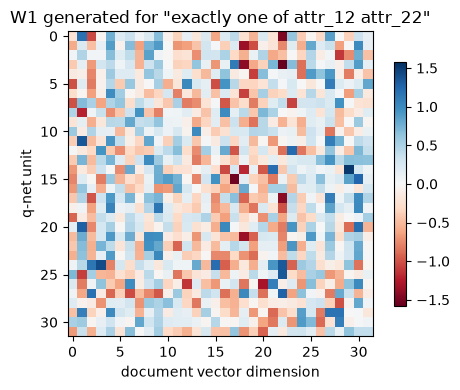

In [5]:
demo_pair = train_pairs[0]
q_xor = pad([query_tokens("xor", demo_pair)])
with torch.no_grad():
    W1, b1, w_out = (t[0] for t in hyp.q_net_params(q_xor))

print(f'query: "{as_text(q_xor[0])}"')
print(f"generated q-net: W1 {tuple(W1.shape)}, b1 {tuple(b1.shape)}, "
      f"w_out {tuple(w_out.shape)} — {W1.numel() + b1.numel() + w_out.numel():,} numbers")

plt.figure(figsize=(5, 4))
plt.imshow(W1, cmap="RdBu", vmin=-W1.abs().max(), vmax=W1.abs().max())
plt.colorbar(shrink=0.8)
plt.title(f'W1 generated for "{as_text(q_xor[0])}"')
plt.xlabel("document vector dimension"); plt.ylabel("q-net unit")
plt.tight_layout(); plt.show()

## Did they learn it, or memorize it?

We test the models on combinations of properties, in documents and in
queries, that were never seen during training; to check that they've found
a general solution and aren't just memorizing the training data. (In the
table, "seen pairs" keeps the training-time queries but ranks new documents;
"unseen pairs" makes even the query combination new.) The score is P@10: of
the ten documents a model ranks highest, how many are actually relevant?

In [6]:
@torch.no_grad()
def p_at_10(model, qtype, eval_pairs, k=10):
    d_vecs = model.d_enc(doc_toks_ho)
    out = []
    for p in eval_pairs:
        s = model.score(pad([query_tokens(qtype, p)]), d_vecs)[0]
        rel = torch.tensor([float(relevant(qtype, x, p)) for x in doc_sets_ho])
        out.append(rel[s.topk(k).indices].mean().item())
    return sum(out) / len(out)


chance = {t: statistics.mean(
    statistics.mean(float(relevant(t, s, p)) for s in doc_sets_ho)
    for p in test_pairs) for t in TYPES}

print(f"{'model':<12}{'query kind':<12}{'seen pairs':>11}{'unseen pairs':>14}{'chance':>9}")
for name, m in [("bi-encoder", bi), ("hypencoder", hyp)]:
    for t in TYPES:
        print(f"{name:<12}{t:<12}{p_at_10(m, t, train_pairs[:EVAL_PAIRS]):>11.2f}"
              f"{p_at_10(m, t, test_pairs[:EVAL_PAIRS]):>14.2f}{chance[t]:>9.3f}")

model       query kind   seen pairs  unseen pairs   chance


bi-encoder  single             1.00          1.00    0.127
bi-encoder  and                0.99          1.00    0.012


bi-encoder  xor                0.01          0.00    0.227


hypencoder  single             1.00          1.00    0.127
hypencoder  and                0.99          0.93    0.012


hypencoder  xor                0.99          0.99    0.227


The bi-encoder is perfect on `single` and `and` — and gets XOR almost
exactly **zero**. Not "didn't learn": it learned the *opposite*. Let's check
the average score each model gives to each kind of document, for XOR queries:

In [7]:
@torch.no_grad()
def class_report(model):
    d_vecs = model.d_enc(doc_toks_ho)
    sums, aucs = {"one": [], "both": [], "neither": []}, []
    for p in test_pairs[:EVAL_PAIRS]:
        s = model.score(pad([query_tokens("xor", p)]), d_vecs)[0]
        one = s[torch.tensor([relevant("xor", x, p) for x in doc_sets_ho])]
        both = s[torch.tensor([p[0] in x and p[1] in x for x in doc_sets_ho])]
        neither = s[torch.tensor([p[0] not in x and p[1] not in x for x in doc_sets_ho])]
        sums["one"].append(one.mean().item())
        sums["both"].append(both.mean().item())
        sums["neither"].append(neither.mean().item())
        aucs.append((one.unsqueeze(1) > both.unsqueeze(0)).float().mean().item())
    return {k: statistics.mean(v) for k, v in sums.items()}, statistics.mean(aucs)


print(f"{'':12}{'only a / only b':>16}{'a and b':>9}{'neither':>9}"
      f"{'  P(one above both)':>20}")
for name, m in [("bi-encoder", bi), ("hypencoder", hyp)]:
    means, a = class_report(m)
    print(f"{name:<12}{means['one']:>16.2f}{means['both']:>9.2f}"
          f"{means['neither']:>9.2f}{a:>20.3f}")

             only a / only b  a and b  neither   P(one above both)


bi-encoder              0.22     2.84    -2.18               0.000
hypencoder              2.24    -1.39    -2.77               0.916


Read the bi-encoder's row: it scores the **a and b** documents *highest* —
above the right answers — essentially every single time. That is not a bug in
training; it's what inner-product scoring reliably converges to. A dot product adds
up evidence: if `a` is worth something and `b` is worth something, then `a`
*and* `b` is worth more, right? "Exactly one" is the statement an inner
product is biased against making - the better it learns the other types of
query, the more perfectly wrong it becomes on this one.

The hypencoder's row shows what changes when the query is allowed to be a
function: the trap documents score *below* the right answers. The non-linearities
in the generated q-net allow it to express "evidence for a and evidence for b, together, is bad".
The information is present in both document representations (which is what allows them to answer the "single" queries).

## The same models, in a search engine's ranking language

In Vespa, ranking is a math expression in the schema (a *rank profile*), and
the engine evaluates it per document. Our two scoring functions translate
line for line:

| model | in torch | as a rank expression |
|---|---|---|
| bi-encoder | `(q @ d.T)`, normalized | `sum(q*docs,x) / sqrt(sum(q*q,x)*sum(docs*docs,x))` |
| hypencoder | `w_out · relu(W1 @ d + b1)` | `sum(max(sum(W1*docs,x)+b1, 0.0)*wout, h)` |

The cell below sends your trained weights and three held-out documents (one
right answer, one hard negative, one unrelated) to Vespa's public
[tensor playground](https://docs.vespa.ai/playground/) and checks the engine
returns the same scores torch computes. It also asks the playground *how* Vespa chooses to
execute the tensor expression:

In [8]:
import urllib.parse
import urllib.request
import json as _json


def playground_eval(cells):
    payload = [{"cell": i, "name": n, "expr": e, "verbose": True}
               for i, (n, e) in enumerate(cells)]
    data = urllib.parse.urlencode({"json": _json.dumps(payload)}).encode()
    req = urllib.request.Request("https://api.search.vespa.ai/playground/eval", data=data)
    with urllib.request.urlopen(req, timeout=30) as r:
        return _json.loads(r.read())


def lit(t, dims):
    vals = ([round(float(v), 6) for v in t] if t.dim() == 1
            else [[round(float(v), 6) for v in row] for row in t])
    return f"tensor<float>({dims}):" + _json.dumps(vals)


one_i = next(i for i, s in enumerate(doc_sets_ho) if relevant("xor", s, demo_pair))
both_i = next(i for i, s in enumerate(doc_sets_ho)
              if demo_pair[0] in s and demo_pair[1] in s)
none_i = next(i for i, s in enumerate(doc_sets_ho)
              if demo_pair[0] not in s and demo_pair[1] not in s)
picks = [one_i, both_i, none_i]

with torch.no_grad():
    q_vec = bi.q_enc(q_xor)[0]
    docs_b = bi.d_enc(doc_toks_ho[picks])
    docs_h = hyp.d_enc(doc_toks_ho[picks])
    torch_bi = bi.score(q_xor, docs_b)[0] / 10  # undo the training-only scale
    torch_hyp = hyp.score(q_xor, docs_h)[0]

result = playground_eval([
    ("docs",  lit(docs_h, f"d[3],x[{D_VEC}]")),
    ("docsb", lit(docs_b, f"d[3],x[{D_VEC}]")),
    ("q",     lit(q_vec, f"x[{D_VEC}]")),
    ("bi_rung",                                        # = BiEncoder.score
     "sum(q*docsb,x) / sqrt(sum(q*q,x) * sum(docsb*docsb,x))"),
    ("W1",   lit(W1, f"h[{D_VEC}],x[{D_VEC}]")),
    ("b1",   lit(b1, f"h[{D_VEC}]")),
    ("wout", lit(w_out, f"h[{D_VEC}]")),
    ("hyp_rung",                                       # = Hypencoder.score
     "sum(max(sum(W1*docs,x)+b1, 0.0)*wout, h)"),
])

by_idx = {c["cell"]: c for c in result}
def scores_of(i):
    return [c["value"] for c in sorted(by_idx[i]["value"]["cells"],
                                       key=lambda c: int(c["address"]["d"]))]
vespa_bi, vespa_hyp = scores_of(3), scores_of(7)

print(f'query: "{as_text(q_xor[0])}"\n')
print(f"{'document':<12}{'torch bi':>10}{'vespa bi':>10}{'torch hyp':>11}{'vespa hyp':>11}")
for i, cls in enumerate(["one-match ✓", "both      ✗", "neither   ✗"]):
    print(f"{cls:<12}{torch_bi[i]:>10.4f}{vespa_bi[i]:>10.4f}"
          f"{torch_hyp[i]:>11.4f}{vespa_hyp[i]:>11.4f}")

diff = max(max(abs(float(t) - v) for t, v in zip(torch_bi, vespa_bi)),
           max(abs(float(t) - v) for t, v in zip(torch_hyp, vespa_hyp)))
assert diff < 2e-3, diff
print(f"\ndifference |torch − vespa| = {diff:.2e}")

plan = [s["class"].split("::")[-1] for s in _json.loads(by_idx[7]["steps"])]
print("q-net execution plan:", ", ".join(p for p in plan if p.endswith("Function")))

query: "exactly one of attr_12 attr_22"

document      torch bi  vespa bi  torch hyp  vespa hyp
one-match ✓     0.0402    0.0402     2.7538     2.7538
both      ✗     0.2732    0.2732    -5.1857    -5.1857
neither   ✗    -0.1873   -0.1873    -2.3793    -2.3793

difference |torch − vespa| = 2.86e-06
q-net execution plan: DenseMatMulFunction, MixedSimpleJoinFunction, JoinWithNumberFunction, DenseXWProductFunction


It should return the same numbers (within floating point variance), and the execution plan shows that such expressions are efficiently executed in Vespa,
just like in pytorch: `DenseXWProductFunction` and friends are
optimized kernels the engine picked after *recognizing* that the (sub)expressions matched.

## Try it

1. `D_VEC=64 STEPS=3000` - with more dimensions, the hypencoder learns the harder XOR query type faster,
   but the bi-encoder still doesn't learn it.
2. `D_VEC=16` - not enough capacity to _really_ learn XOR: P@10 still looks decent,
   but rerun the class averages and watch the "a and b" row. This is why we check...
3. Try adding a fourth type of query - ("at most one of"? "a unless b"?) and see which types work, and which
   model needs how much width to learn it!

# Run the real, full-size hypencoder model in Vespa!

If you'd like to try running the non-toy hypencoder checkpoints from the paper on your docs in a real production-ready search engine: check out our published sample app!

- [Vespa hypencoder sample app](https://github.com/vespa-engine/sample-apps/tree/master/hypencoder)

## References
- [A video walkthrough](https://youtu.be/-xWBoXtI7IU) of how the paper turns
  query token embeddings into network weights, in detail. This video is great if you'd like to get a deeper explanation of exactly how the hypencoder model produces the q-net, or their approximate search algorithm which we haven't covered.
- [The Hypencoder paper](https://arxiv.org/abs/2502.05364) (Killingback, Zeng &
  Zamani, SIGIR 2025)